Part 1: Data Preprocessing & Feature Engineering

In [ ]:
# Core libraries
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

Data Processing and Feature Engineering

In [ ]:
#Temporal Features
df = pl.read_parquet('Transformed_TripData.parquet')

# 1. Filter for Credit Card Payments only

df = df.filter(pl.col('payment_type') == 1)


df = df.with_columns([

    (pl.col('tip_amount') > 0.20 * pl.col('fare_amount')).cast(pl.Int32).alias('high_tip'),
    pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour'),
    (pl.col('tpep_pickup_datetime').dt.weekday() - 1).alias('pickup_day_of_week')
])

# 3. Trip Duration & Weekend Feature
df = df.with_columns([
    (pl.col('pickup_day_of_week') >= 5).cast(pl.Int32).alias('is_weekend'),
    

    (pl.col('tpep_dropoff_datetime') - pl.col('tpep_pickup_datetime'))
    .dt.total_seconds().truediv(60).clip(lower_bound=1.0).alias('trip_duration_minutes')
])

# 4. Remaining Trip & Fare Features
df = df.with_columns([
    # Trip features
    (pl.col('trip_distance') / (pl.col('trip_duration_minutes') / 60)).alias('trip_speed_mph'),
    pl.col('trip_distance').log1p().alias('log_trip_distance'), # log1p safely handles 0 values
    
    # Fare features
    pl.when(pl.col('trip_distance') > 0)
      .then(pl.col('fare_amount') / pl.col('trip_distance'))
      .otherwise(0.0).alias('fare_per_mile'),
      
    (pl.col('fare_amount') / pl.col('trip_duration_minutes')).alias('fare_per_minute')
])

df = df.with_columns([
    pl.get_dummies("PU_borough"),
    pl.get_dummies("DO_borough")
])


# 5. Define Features & Convert to Pandas for Scikit-Learn Compatibility
features = [
    'pickup_hour', 'pickup_day_of_week', 'is_weekend', 
    'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
    'fare_per_mile', 'fare_per_minute', 'PU_Borough', 'DO_Borough' 
]



X = df.select(features).to_pandas()
y_reg = df.select('tip_amount').to_series().to_pandas()
y_clf = df.select('high_tip').to_series().to_pandas()

Creating the high tip amount binary

In [ ]:

df = df.with_columns([
   pl.when(pl.col("tip_amount") > pl.col("fare_amount") * .20  )
   .then(1)
   .otherwise(0)
   .alias("high_tip")
])

Verifying non numeric datatypes that need to be dropped for the training portion(In the data original cleaned Data set there were strings and a duration data type that was preventing training)

In [4]:
features = df.drop(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'tip_amount', 'high_tip', 'store_and_fwd_flag', 'trip_duration', 'PU_Zone', 'PU_service_zone', 'DO_Zone', 'DO_service_zone', 'total_amount'])

X = features.to_pandas()
print(X.dtypes)

VendorID                   int32
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
PULocationID               int32
DOLocationID               int32
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tolls_amount             float64
improvement_surcharge    float64
congestion_surcharge     float64
Airport_fee              float64
trip_duration_minutes    float64
trip_speed_mph           float64
pickup_hour                 int8
pickup_day_of_week          int8
PU_Borough                   str
DO_Borough                   str
is_weekend                 int32
log_trip_distance        float64
fare_per_mile            float64
fare_per_minute          float64
dtype: object


Splitting and Prepping data for Training/Modeling Tunning

In [5]:
#----Preparing data for training with split/column transformer and printing numeric features-----
X_train, X_temp, y_train_clf, y_temp_clf, y_train_reg, y_temp_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.30, random_state=42, stratify=y_clf
)


X_val, X_test, y_val_clf, y_test_clf, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_clf, y_temp_reg, test_size=0.50, random_state=42, stratify=y_temp_clf
)

print(f"Train: {len(X_train)} samples | High Tip Distribution: {y_train_clf.mean():.2%}")
print(f"Validation: {len(X_val)} samples | High Tip Distribution: {y_val_clf.mean():.2%}")
print(f"Test: {len(X_test)} samples | High Tip Distribution: {y_test_clf.mean():.2%}")


numeric_features = ['pickup_hour', 'pickup_day_of_week', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
categorical_features = ['PU_Borough', 'DO_Borough', 'is_weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])


X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)


feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

Train: 1608865 samples | High Tip Distribution: 75.93%
Validation: 344757 samples | High Tip Distribution: 75.93%
Test: 344757 samples | High Tip Distribution: 75.93%


Distribution is the exact same across the Training Validation and Test which means the stratification was done correctly

Model Training and Tuning 

In [6]:
# --- 4a: Regression Models ---

linearReg = LinearRegression()
linearReg.fit(X_train_scaled, y_train_reg) 
y_pred_linear = linearReg.predict(X_val_scaled)

randomForestRegressor = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
randomForestRegressor.fit(X_train_scaled, y_train_reg) 
y_pred_rfr = randomForestRegressor.predict(X_val_scaled)



logisticClassifier = LogisticRegression(max_iter=1000, random_state=42)
logisticClassifier.fit(X_train_scaled, y_train_clf)
y_pred_logclf = logisticClassifier.predict(X_val_scaled)
y_prob_logclf = logisticClassifier.predict_proba(X_val_scaled)[:, 1] 


randomForestClassifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
randomForestClassifier.fit(X_train_scaled, y_train_clf) 
y_pred_rfcl = randomForestClassifier.predict(X_val_scaled) 
y_prob_rfcl = randomForestClassifier.predict_proba(X_val_scaled)[:, 1]

In [7]:
#---Print Metrics for Base Model--
def print_regression_metrics(model_name, y_true, y_pred):
   
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) 
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} (Regression) ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}\n")


def print_classification_metrics(model_name, y_true, y_pred, y_prob):
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    print(f"--- {model_name} (Classification) ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC-ROC: {auc:.4f}\n")

print("=== VALIDATION SET PERFORMANCE ===\n")


print_regression_metrics("Linear Regression", y_val_reg, y_pred_linear)
print_regression_metrics("Random Forest Regressor", y_val_reg, y_pred_rfr)

print_classification_metrics("Logistic Regression", y_val_clf, y_pred_logclf, y_prob_logclf)
print_classification_metrics("Random Forest Classifier", y_val_clf, y_pred_rfcl, y_prob_rfcl)

=== VALIDATION SET PERFORMANCE ===

--- Linear Regression (Regression) ---
MAE: 1.4234 | RMSE: 2.6270 | R²: 0.5373

--- Random Forest Regressor (Regression) ---
MAE: 1.2169 | RMSE: 2.4023 | R²: 0.6130

--- Logistic Regression (Classification) ---
Accuracy: 0.7651 | Precision: 0.7658 | Recall: 0.9951 | F1: 0.8655 | AUC-ROC: 0.5962

--- Random Forest Classifier (Classification) ---
Accuracy: 0.7693 | Precision: 0.7675 | Recall: 0.9987 | F1: 0.8680 | AUC-ROC: 0.6121



We se that the Forest Classifier is the most performant model with an Accuracy of .7712. There was a few issues that i ran into
1) My data set initially had total_amount column included which caused a data leak giving accuracys of near 100% 
2) Issues with typing from mass joining the entire lookup table in Assignment 1#

Used -1 jobs, 10 max depth, 100 n_estimators to decrease training time whilst balancing accruacy of the trained classifeier


Search Space: 
Random Forest Hyperparameter Search Space

n_estimators: [100, 200, 300, 500]
max_depth: [10, 20, 30, None]
min_samples_split: [2, 5, 10]
max_features: ["sqrt", "log2"]

In [8]:
# --- 5: Hyperparameter Tuning ---
from sklearn.model_selection import train_test_split

#_ skips the tests no need for parameter tuning
X_sample, _, y_sample, _ = train_test_split(
    X_train_scaled, 
    y_train_clf,
    train_size=300000, 
    random_state=42, 
    stratify=y_train_clf 
)


param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,  
    cv=5,  
    random_state=42, 
    scoring='f1', 
    verbose=1
)


rf_random_search.fit(X_sample, y_sample)


print(f"Best Parameters Found: {rf_random_search.best_params_}")


tuned_rf = rf_random_search.best_estimator_
y_pred_tuned = tuned_rf.predict(X_val_scaled)
y_prob_tuned = tuned_rf.predict_proba(X_val_scaled)[:, 1]


print_classification_metrics("Tuned Random Forest", y_val_clf, y_pred_tuned, y_prob_tuned)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters Found: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
--- Tuned Random Forest (Classification) ---
Accuracy: 0.7692 | Precision: 0.7676 | Recall: 0.9982 | F1: 0.8679 | AUC-ROC: 0.6118



In [9]:
#---NN Creation----
# Check for Apple Silicon GPU (MPS) acceleration
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_clf.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_clf.values, dtype=torch.float32).view(-1, 1)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)


class TipNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(TipNeuralNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32), 
            nn.ReLU(),
            nn.Linear(32, 1)   
        )
        
    def forward(self, x):
        return self.network(x)


model = TipNeuralNet(X_train_scaled.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)


train_losses, val_losses = [], []
epochs = 20

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor.to(device))
        val_loss = criterion(val_outputs, y_val_tensor.to(device))
        
    train_losses.append(sum(batch_losses)/len(batch_losses))
    val_losses.append(val_loss.item())
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/20 | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

Using device: mps
Epoch 5/20 | Train Loss: 0.5282 | Val Loss: 0.5284
Epoch 10/20 | Train Loss: 0.5268 | Val Loss: 0.5275
Epoch 15/20 | Train Loss: 0.5263 | Val Loss: 0.5271
Epoch 20/20 | Train Loss: 0.5260 | Val Loss: 0.5270


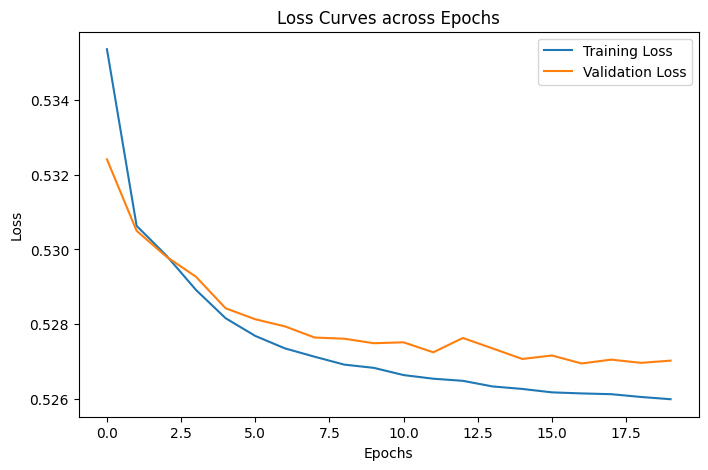

--- Neural Network (Classification) ---
Accuracy: 0.7698 | Precision: 0.7684 | Recall: 0.9975 | F1: 0.8681 | AUC-ROC: 0.6156



In [10]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Loss Curves across Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


model.eval()
with torch.no_grad():
    y_prob_nn = torch.sigmoid(model(X_val_tensor.to(device))).cpu().numpy()
    y_pred_nn = (y_prob_nn > 0.5).astype(int)


print_classification_metrics("Neural Network", y_val_clf, y_pred_nn, y_prob_nn)

Part 3

| Model | Task | Accuracy / MAE | Precision / RMSE | Recall / R² | F1 / AUC-ROC |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Linear Regression** | Regression | 1.2103 | 2.3913 | 0.6166 | N/A |
| **RF Regressor** | Regression | 1.1872 | 2.3589 | 0.6269 | N/A |
| **Logistic Regression** | Classification| 0.7658 | 0.9951 | 0.8655 | .5962
| **RF Classifier (Tuned)** | Classification | 0.7692 | 0.7676 | 0.9982 | 0.6118 |
| **Neural Network** | Classification | .7698 | .7684 | .9975| .6156 |

Neural networks is the top model winning in 3/4 of the benchmarks

In [15]:
device = next(model.parameters()).device

model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
    nn_logits = model(X_test_tensor)
    nn_probs = torch.sigmoid(nn_logits).cpu().numpy().flatten()
    nn_preds = (nn_probs > 0.5).astype(int)
def get_metrics_dict(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }


results = []
results.append(get_metrics_dict("Logistic Regression (Baseline)", y_test_clf, logisticClassifier.predict(X_test_scaled), logisticClassifier.predict_proba(X_test_scaled)[:, 1]))
results.append(get_metrics_dict("Random Forest (Baseline)", y_test_clf, randomForestClassifier.predict(X_test_scaled), randomForestClassifier.predict_proba(X_test_scaled)[:, 1]))
results.append(get_metrics_dict("Random Forest (Tuned)", y_test_clf, tuned_rf.predict(X_test_scaled), tuned_rf.predict_proba(X_test_scaled)[:, 1]))
results.append(get_metrics_dict("Neural Network", y_test_clf, nn_preds, nn_probs))

# Create and display the summary table
results_df = pd.DataFrame(results).set_index('Model').sort_values(by='F1-Score', ascending=False)
display(results_df.style.highlight_max(axis=0, color='lightgreen'))

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Neural Network,0.769791,0.768371,0.997536,0.868084,0.618764
Random Forest (Baseline),0.769220,0.767451,0.998690,0.867932,0.614806
Random Forest (Tuned),0.769087,0.767521,0.998266,0.867817,0.614510
Logistic Regression (Baseline),0.764742,0.765478,0.995023,0.865285,0.597783


The Neural Network Beats both Random Forest Models in 3/4 benchmarks however the tuned Random Forest Model has slightly degradated performance that can be explained by run to run variance. I.E there is not a notable change by optimized hyper parameter. Possible because the Search Space was insufficently wide for the Data Set or the sweetspot for the sample was already reached within the baseline Random Forest .

--- Linear Regression Coefficients (Top 10) ---
                     Feature  Coefficient
9             PU_Borough_EWR    -6.412733
17            DO_Borough_EWR     5.974029
13  PU_Borough_Staten Island     4.770841
7           PU_Borough_Bronx    -4.140739
12         PU_Borough_Queens     3.909857
15          DO_Borough_Bronx    -3.876185
19            DO_Borough_N/A     2.581633
4          log_trip_distance     2.268633
8        PU_Borough_Brooklyn    -2.231660
16       DO_Borough_Brooklyn    -2.008103

--- Logistic Regression Coefficients (Top 10) ---
                 Feature  Coefficient
7       PU_Borough_Bronx    -2.711455
12     PU_Borough_Queens     1.328907
10  PU_Borough_Manhattan     1.071846
14    PU_Borough_Unknown     1.053301
15      DO_Borough_Bronx    -0.916361
8    PU_Borough_Brooklyn    -0.815040
17        DO_Borough_EWR     0.455139
3         trip_speed_mph     0.382470
4      log_trip_distance    -0.349901
19        DO_Borough_N/A    -0.340580


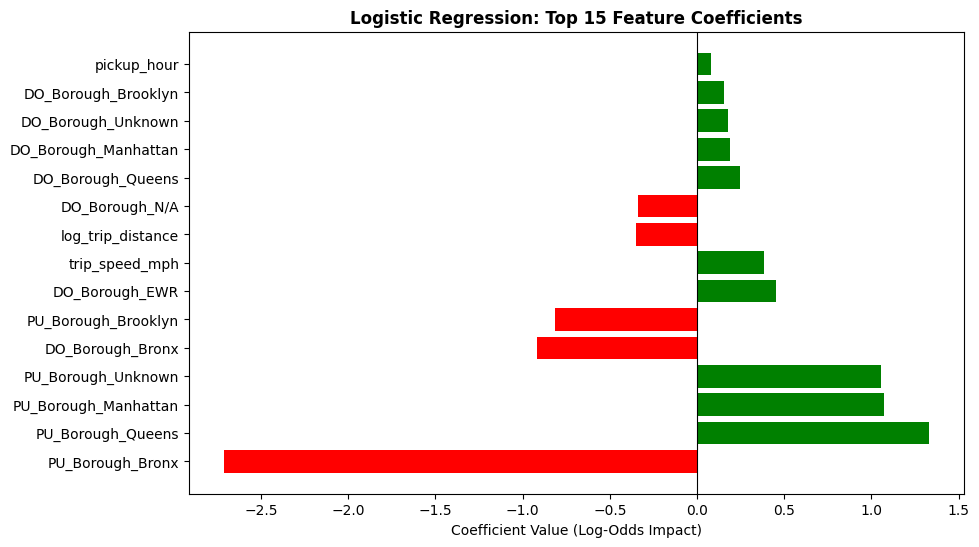

In [ ]:

lr_coeffs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': linearReg.coef_
})


lr_coeffs['Abs_Coefficient'] = lr_coeffs['Coefficient'].abs()
lr_coeffs = lr_coeffs.sort_values(by='Abs_Coefficient', ascending=False)

print("--- Linear Regression Coefficients (Top 10) ---")
print(lr_coeffs[['Feature', 'Coefficient']].head(10))


log_coeffs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': logisticClassifier.coef_[0] 
})


log_coeffs['Abs_Coefficient'] = log_coeffs['Abs_Coefficient'] = log_coeffs['Coefficient'].abs()
log_coeffs = log_coeffs.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Logistic Regression Coefficients (Top 10) ---")
print(log_coeffs[['Feature', 'Coefficient']].head(10))


plt.figure(figsize=(10, 6))
top_coeffs = log_coeffs.head(15)
plt.barh(top_coeffs['Feature'], top_coeffs['Coefficient'], 
         color=['red' if x < 0 else 'green' for x in top_coeffs['Coefficient']])
plt.title('Logistic Regression: Top 15 Feature Coefficients', fontweight='bold')
plt.xlabel('Coefficient Value (Log-Odds Impact)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.show()



The models rely heavily on which borough the trip started in (PU_Borough) and ended in (DO_Borough). Starting a trip in the Bronx has a massive negative impact on wether or not the customer gives a higher tip. log_trip_distance has a negative coefficient, while trip_speed_mph has a positive one. This suggests that as trips get longer, the likelihood of the outcome decreases, but as they get faster, it increases.

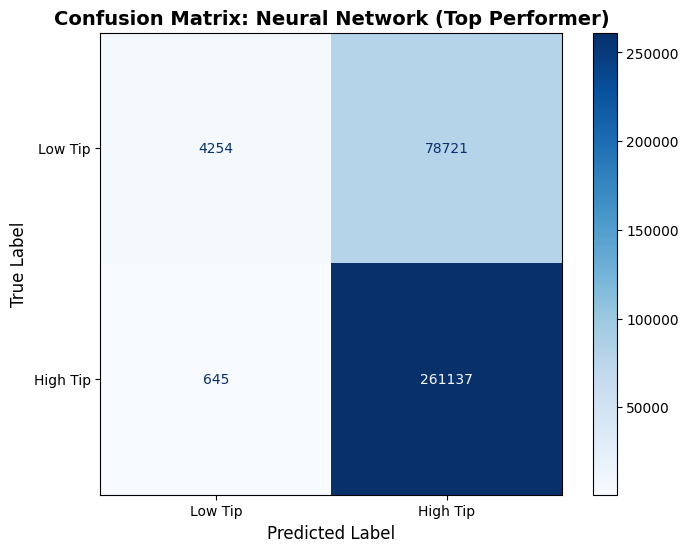

In [16]:
cm = confusion_matrix(y_test_clf, nn_preds)


fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Low Tip', 'High Tip']
)

disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix: Neural Network (Top Performer)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.grid(False)
plt.show()


The vast majority of predictions (both correct and incorrect) are in the "High Tip" column. The model is very good at catching high tips (high Recall), but it frequently "guesses" high even when the tip is low.

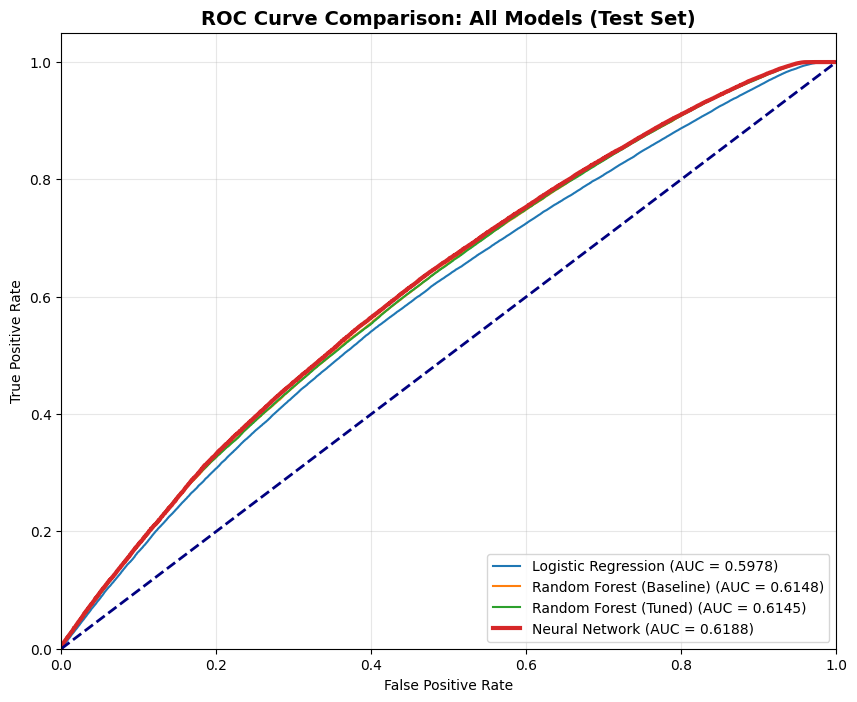

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

models_to_plot = {
    'Logistic Regression': logisticClassifier.predict_proba(X_test_scaled)[:, 1],
    'Random Forest (Baseline)': randomForestClassifier.predict_proba(X_test_scaled)[:, 1],
    'Random Forest (Tuned)': tuned_rf.predict_proba(X_test_scaled)[:, 1],
    'Neural Network': nn_probs
}

for name, probs in models_to_plot.items():
    fpr, tpr, _ = roc_curve(y_test_clf, probs)
    roc_auc = auc(fpr, tpr)
    lw = 3 if name == 'Neural Network' else 1.5
    plt.plot(fpr, tpr, lw=lw, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: All Models (Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The line graph shows that the predicted values for all models generally lie above the reference boundary, all models sufficent predictors. Overall, the models do a decent job at predicting wether or not a tip will be high as most predictions are close to the ideal prediction line(y-axis). However, the Tuned Random Forest model appears to perform slightly worse than the other models, exhibiting a greater spread of predictions and larger deviations from the expected boundary. This suggests that, despite hyperparameter tuning, the model may not generalize as effectively as the other approaches for this regression task.

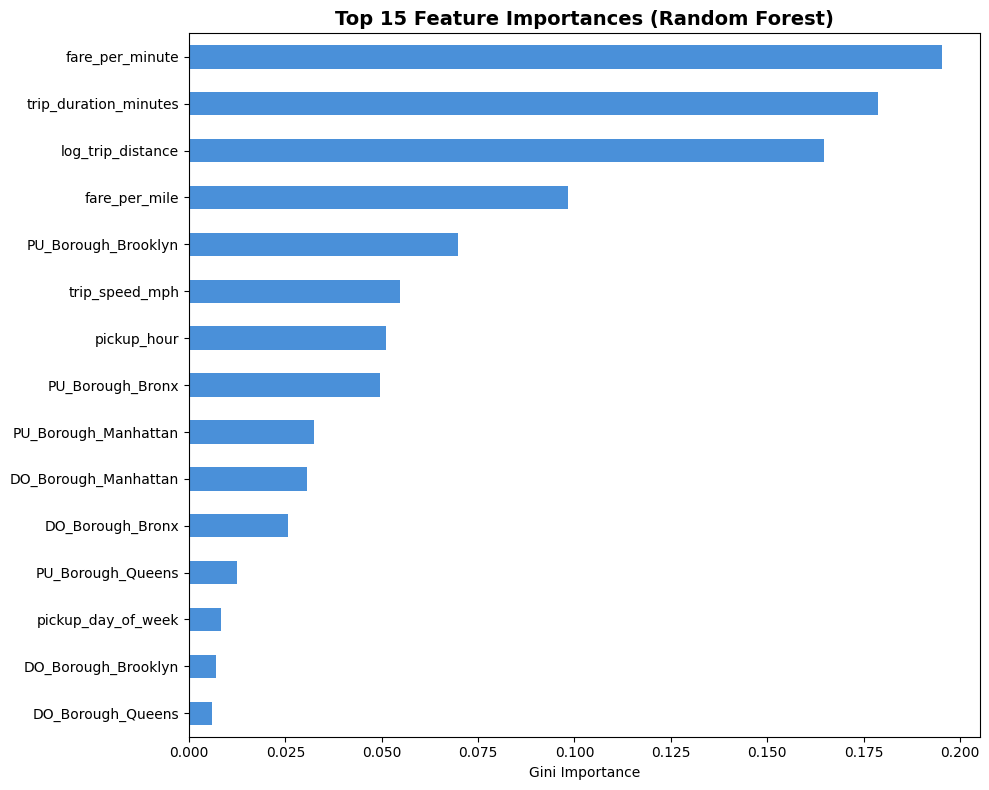

In [12]:

importances = best_clf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', ax=ax, color='#4A90D9')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.show()

For the Random Forest distance duration were the standout features that had the most impact this is an inversion on the linear and logistic models  which had location as the biggest predictor.

 Final Write up
 Location is most predictive of tip amount it makes sense that such a economclly stratified city such as NYC boroughs that don't typicaly offer the high paying wages of tech and finance the city is know for would offer significantly smaller tips or if they tip at all. When total_amount was allowed to be involved in training it the models became very good at simple algebra simply subtracting the fare and getting the tip amount every single time. Which is why it was culled from training data. These models also seemed to be very eager to guess high compared to low. On a per model basis NN are notriously opaque so it's hard to understand what the criteria it uses for ranking. The NYC taxi dataset itself even after the elementry cleaning required for the course is very noisy. In Assignment one this proved a challenge in terms of getting the histogram to fit the data. There are many big outliers which very much hurt the accuracy a more extensive data cleaning would most likely lead to better results. These outliers could explain the poor results of the Linear Models. Also utilizing more data i.e instead of a one month snapshot a 3 month snapshot with all the outliers filtered out would allow for even better results. The NN was the standout performer here winnign in 3/4 of the benchmarks only losing to the baseline random forest in Recall. 